In [1]:
import numpy as np
import matplotlib.pyplot as plt
import esigmapy

/home/samanwaya/esigmapy-dev/esigmapy/esigmapy/generator.py:10: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


No version information file '.version' found


In [2]:
import os
x=os.environ.get("ModePNOrder")
print('Poof!') if x is None else int(x)

3

In [3]:
from esigmapy.python_codes import generator_python as gp

m1 = 20.0  # masses (in solar masses)
m2 = 30.0
spin1z = 0.5  # dimensionless spins
spin2z = -0.3
eccentricity = 0.15  # starting eccentricity
mean_anomaly = 60 * np.pi / 180.0  # starting mean anomaly
modes_to_use = [(2, 2), (2, -2)]  # Only using the (2,2) mode

distance = 400.0  # source luminosity distance (in Mpc)
inclination = 30 * np.pi / 180.0  # orbital inclination with line-of-sight

f_low = 20.0  # starting frequency (in Hz)
delta_t = 1 / 2**12  # time grid-spacing (in s)

# hp, hc = gp.get_imr_esigma_waveform(
#     mass1=m1,
#     mass2=m2,
#     spin1z=spin1z,
#     spin2z=spin2z,
#     eccentricity=eccentricity,
#     mean_anomaly=mean_anomaly,
#     distance=distance,
#     inclination=inclination,
#     f_lower=f_low,
#     delta_t=delta_t,
#     modes_to_use=modes_to_use,
# )

modes_py = gp.get_inspiral_esigma_modes_py(
    mass1=m1,
    mass2=m2,
    spin1z=spin1z,
    spin2z=spin2z,
    eccentricity=eccentricity,
    mean_anomaly=mean_anomaly,
    distance=distance,
    # inclination=inclination,
    f_lower=f_low,
    delta_t=delta_t,
    modes_to_use=modes_to_use,
    verbose=True
)


Orbital evolution took: 7.503528344001097 seconds
3
3
Modes generation took: 0.2238857789998292 seconds


In [4]:
# m1 = 20.0  # masses (in solar masses)
# m2 = 30.0
# spin1z = 0.5  # dimensionless spins
# spin2z = -0.3
# eccentricity = 0.15  # starting eccentricity
# mean_anomaly = 60 * np.pi / 180.0  # starting mean anomaly
# modes_to_use = [(2, 2), (2, -2)]  # Only using the (2,2) mode

# distance = 400.0  # source luminosity distance (in Mpc)
# inclination = 30 * np.pi / 180.0  # orbital inclination with line-of-sight

# f_low = 20.0  # starting frequency (in Hz)
# delta_t = 1 / 2**12  # time grid-spacing (in s)

# hp, hc = gp.get_imr_esigma_waveform(
#     mass1=m1,
#     mass2=m2,
#     spin1z=spin1z,
#     spin2z=spin2z,
#     eccentricity=eccentricity,
#     mean_anomaly=mean_anomaly,
#     distance=distance,
#     inclination=inclination,
#     f_lower=f_low,
#     delta_t=delta_t,
#     modes_to_use=modes_to_use,
# )

modes_c = esigmapy.get_inspiral_esigma_modes(
    mass1=m1,
    mass2=m2,
    spin1z=spin1z,
    spin2z=spin2z,
    eccentricity=eccentricity,
    mean_anomaly=mean_anomaly,
    distance=distance,
    # inclination=inclination,
    f_lower=f_low,
    delta_t=delta_t,
    modes_to_use=modes_to_use,
    verbose=True
)


Orbital evolution took: 0.05242229400028009 seconds
Modes generation took: 0.14869545600231504 seconds


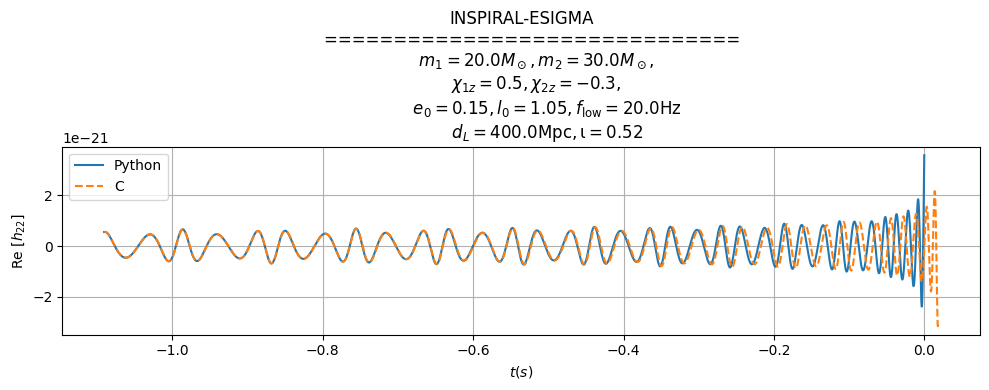

In [6]:
hp22_py_real = modes_py[(2, 2)].real()
hp22_c_real = modes_c[(2, 2)].real()
plt.figure(figsize=(10, 4))
plt.title(
    rf"""INSPIRAL-ESIGMA
    ==============================
      $m_1={m1} M_\odot, m_2={m2} M_\odot$, 
      $\chi_{{1z}}={spin1z}, \chi_{{2z}}={spin2z}$, 
          $e_0={eccentricity}, l_0={mean_anomaly:.2f}, f_{{\rm{{low}}}}={f_low}\rm{{Hz}}$
          $d_L={distance}\rm{{Mpc}}, \iota={inclination:.2f}$"""
)
# hp.plot(label=r"$h_+$")
# hc.plot(label=r"$h_\times$")

plt.plot(hp22_py_real.sample_times,hp22_py_real,label='Python')
plt.plot(hp22_c_real.sample_times+0.0185,hp22_c_real,label='C',ls='--')

plt.xlabel(r"$t (s)$")
plt.ylabel(r"Re [$h_{22}$]")
plt.legend()
plt.grid()
plt.tight_layout()

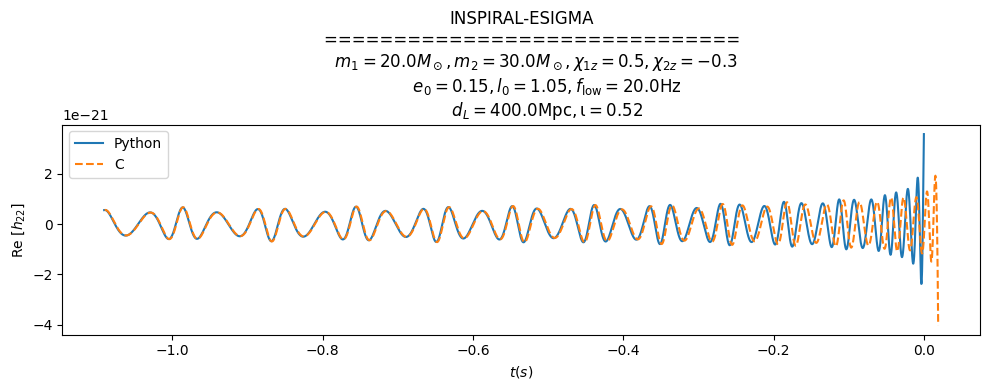

In [4]:
hp22_py_real = modes_py[(2, 2)].real()
hp22_c_real = modes_c[(2, 2)].real()
plt.figure(figsize=(10, 4))
plt.title(
    rf"""INSPIRAL-ESIGMA
    ==============================
      $m_1={m1} M_\odot, m_2={m2} M_\odot, \chi_{{1z}}={spin1z}, \chi_{{2z}}={spin2z}$ 
          $e_0={eccentricity}, l_0={mean_anomaly:.2f}, f_{{\rm{{low}}}}={f_low}\rm{{Hz}}$
          $d_L={distance}\rm{{Mpc}}, \iota={inclination:.2f}$"""
)
# hp.plot(label=r"$h_+$")
# hc.plot(label=r"$h_\times$")

plt.plot(hp22_py_real.sample_times,hp22_py_real,label='Python')
plt.plot(hp22_c_real.sample_times+0.019,hp22_c_real,label='C',ls='--')

plt.xlabel(r"$t (s)$")
plt.ylabel(r"Re [$h_{22}$]")
plt.legend()
plt.tight_layout()

dict_keys([(2, 2), (2, -2)])


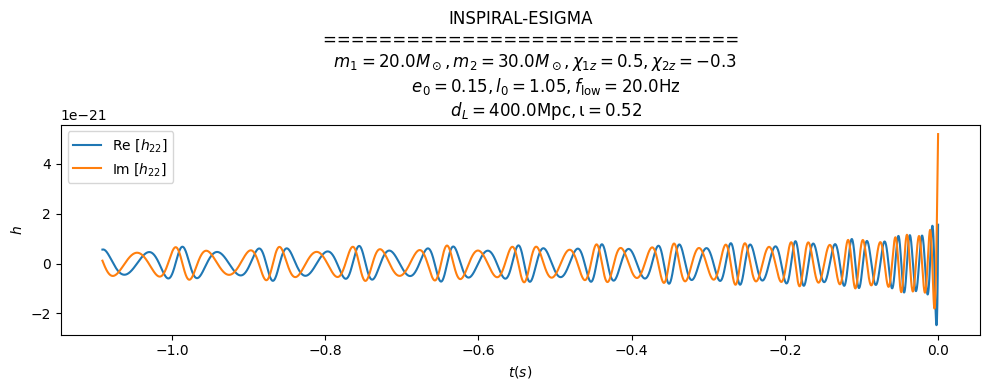

In [5]:
print(modes_py.keys())
hp22 = modes_py[(2, 2)].real()
hc22 = modes_py[(2, 2)].imag()
plt.figure(figsize=(10, 4))
plt.title(
    rf"""INSPIRAL-ESIGMA
    ==============================
      $m_1={m1} M_\odot, m_2={m2} M_\odot, \chi_{{1z}}={spin1z}, \chi_{{2z}}={spin2z}$ 
          $e_0={eccentricity}, l_0={mean_anomaly:.2f}, f_{{\rm{{low}}}}={f_low}\rm{{Hz}}$
          $d_L={distance}\rm{{Mpc}}, \iota={inclination:.2f}$"""
)
# hp.plot(label=r"$h_+$")
# hc.plot(label=r"$h_\times$")

plt.plot(hp22.sample_times,hp22,label=r"Re [$h_{22}$]")
plt.plot(hc22.sample_times,hc22,label=r"Im [$h_{22}$]")

plt.xlabel(r"$t (s)$")
plt.ylabel(r"$h$")
plt.legend()
plt.tight_layout()